In [2]:
import pandas as pd

path = '../data/insurance.csv'
df = pd.read_csv(path)
print(df)


      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [4]:
df["charges"].max()

np.float64(63770.42801)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
# fit_transform ordenará alfabéticamente: 'no' será 0 y 'yes' será 1
df['smoker'] = encoder.fit_transform(df['smoker']) 



In [14]:
correlacion = df.select_dtypes(include=["number"]).corr()
correlacion

,age,bmi,children,smoker,charges
age,1.000000,0.109272,0.042469,-0.025019,0.299008
bmi,0.109272,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.198341,0.067998,0.787251,1.000000


In [6]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


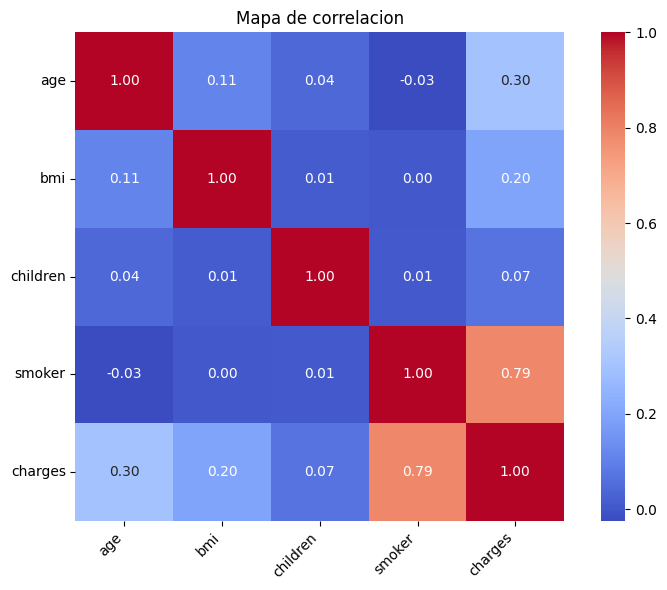

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,      # muestra números dentro de cada celda
    fmt=".2f",       # 2 decimales
    cmap="coolwarm",
    square=True
)
plt.title("Mapa de correlacion")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np

# Detectar y quitar outliers con Z-Score
columnas_numericas = df.select_dtypes(include=["number"]).columns

# Z = (x - media) / desviación estándar
media = df[columnas_numericas].mean()
desv_std = df[columnas_numericas].std(ddof=0).replace(0, np.nan)  # evita división por 0

z_scores = ((df[columnas_numericas] - media) / desv_std).abs()

# True para filas sin outliers en ninguna columna numérica
umbral = 3
mascara_sin_outliers = ((z_scores < umbral) | z_scores.isna()).all(axis=1)

df_sin_outliers = df[mascara_sin_outliers].copy()
df_outliers = df[~mascara_sin_outliers].copy()

print(f"Filas originales: {len(df)}")
print(f"Filas sin outliers: {len(df_sin_outliers)}")
print(f"Outliers detectados: {len(df_outliers)}")

Filas originales: 1338
Filas sin outliers: 1309
Outliers detectados: 29


In [19]:
# Guardar el dataset final (sin outliers y con 'smoker' codificado) en la carpeta data
ruta_salida = "../data/insurance_eda.csv"
df_sin_outliers.to_csv(ruta_salida, index=False)

print(f"CSV guardado en: {ruta_salida}")
print(f"Filas: {len(df_sin_outliers)} | Columnas: {df_sin_outliers.shape[1]}")

CSV guardado en: ../data/insurance_eda.csv
Filas: 1309 | Columnas: 7
